Win Rate by Bet Type:
     bet_type  win_rate
0   moneyline      0.75
1  over/under      0.50
2      spread      0.50
Betting Returns by Bet Type:
     bet_type  returns
0   moneyline     60.0
1  over/under    -16.0
2      spread      2.5


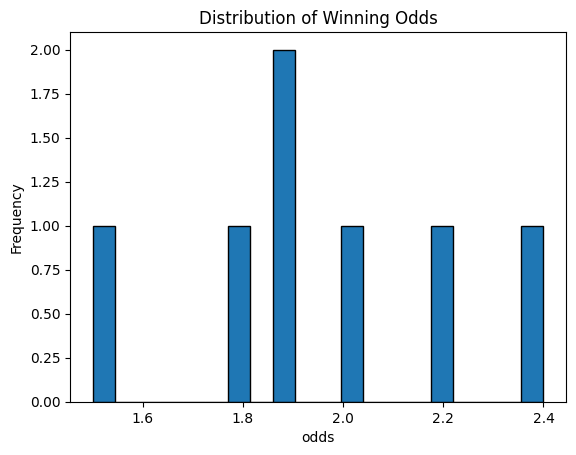

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Read the CSV file
betting_data = pd.read_csv('sports_betting_data.csv')  
# Calculate the win rate
win_rate = betting_data[betting_data['bet_outcome'] == 'win'].groupby('bet_type')['bet_id'].count() / betting_data.groupby('bet_type')['bet_id'].count()
win_rate = win_rate.reset_index().rename(columns={'bet_id': 'win_rate'})
print("Win Rate by Bet Type:")
print(win_rate)
# Calculate the betting returns
betting_data['returns'] = np.where(betting_data['bet_outcome'] == 'win', betting_data['bet_amount'] * (betting_data['odds'] -1), -betting_data['bet_amount'])
betting_returns = betting_data.groupby('bet_type')['returns'].sum().reset_index()
print("Betting Returns by Bet Type:")
print(betting_returns)
# Filter the winning bets
winning_bets = betting_data[betting_data['bet_outcome'] == 'win']
# Set up the histogram
plt.hist(winning_bets['odds'], bins=20, edgecolor= 'black')
plt.xlabel("odds")
plt.ylabel("Frequency")
plt.title("Distribution of Winning Odds")
plt.show()